🔬 Analizando Estructura3.csv...


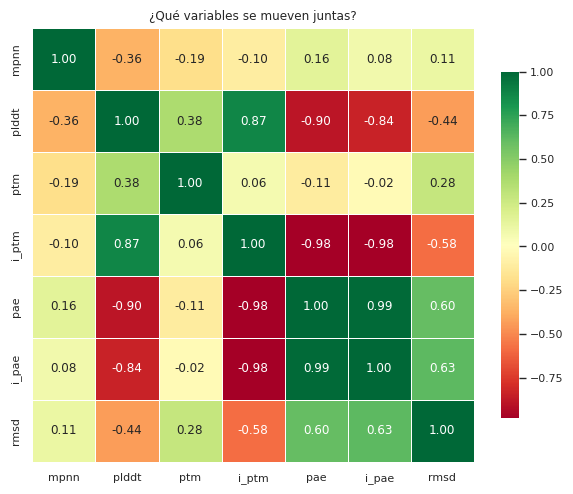

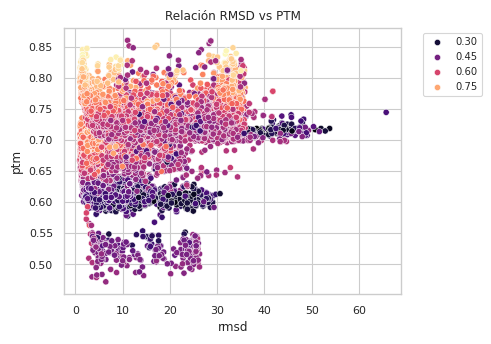

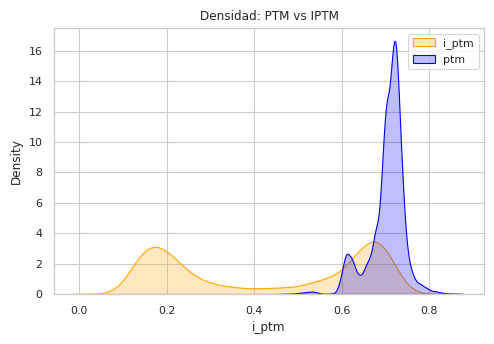

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset original
df = pd.read_csv('../data/Estructuras3.csv')

def run_deep_eda(df):
    sns.set_theme(style="whitegrid")
    # Reducimos el tamaño de fuente global para que quepa en fotos pequeñas
    sns.set_context("paper", font_scale=0.9) 
    
    print("🔬 Analizando Estructura3.csv...")

    # 1. Matriz de Correlación (Más compacta)
    plt.figure(figsize=(6, 5)) # Reducido de 10x8
    cols_interes = ['mpnn', 'plddt', 'ptm', 'i_ptm', 'pae', 'i_pae', 'rmsd']
    corr = df[cols_interes].corr()
    
    sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("¿Qué variables se mueven juntas?")
    plt.tight_layout()
    plt.show()

    # 2. Relación RMSD vs PTM (Mini)
    plt.figure(figsize=(5, 3.5)) # Reducido de 8x5
    sns.scatterplot(data=df, x='rmsd', y='ptm', hue='plddt', palette='magma', s=20) # s=20 achica los puntos
    plt.title("Relación RMSD vs PTM")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Leyenda fuera para no tapar
    plt.tight_layout()
    plt.show()

    # 3. Distribución (Mini)
    plt.figure(figsize=(5, 3.5))
    sns.kdeplot(df['i_ptm'], fill=True, color="orange", label="i_ptm")
    sns.kdeplot(df['ptm'], fill=True, color="blue", label="ptm")
    plt.title("Densidad: PTM vs IPTM")
    plt.legend()
    plt.tight_layout()
    plt.show()
run_deep_eda(df)

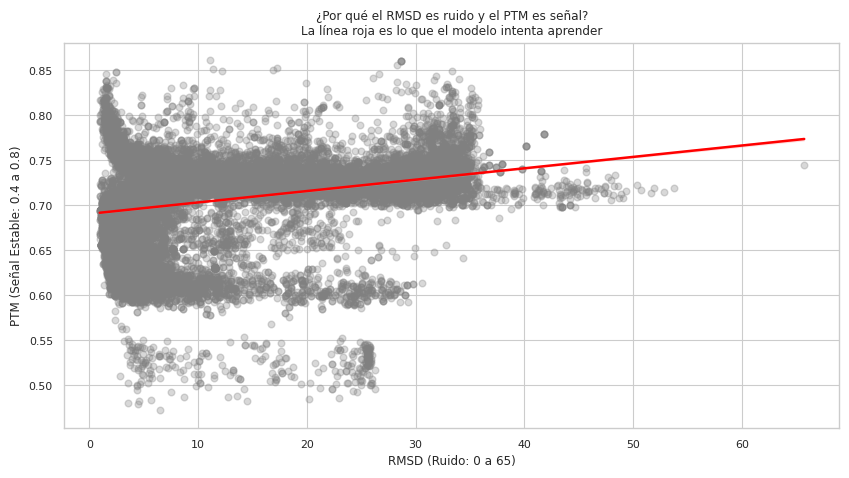

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_final_clean_eda(df):
    plt.figure(figsize=(10, 5))
    
    # Solo graficamos la relación clave: RMSD vs PTM
    # Filtramos el ruido visual para entender la tendencia
    sns.regplot(data=df, x='rmsd', y='ptm', 
                scatter_kws={'alpha':0.3, 'color':'gray'}, 
                line_kws={'color':'red'})
    
    plt.title("¿Por qué el RMSD es ruido y el PTM es señal?\nLa línea roja es lo que el modelo intenta aprender")
    plt.xlabel("RMSD (Ruido: 0 a 65)")
    plt.ylabel("PTM (Señal Estable: 0.4 a 0.8)")
    plt.show()

plot_final_clean_eda(df)

/tmp/ipykernel_22431/1540734549.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['ptm'], shade=True, color="blue", label="PTM (Señal)")
/tmp/ipykernel_22431/1540734549.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['i_ptm'], shade=True, color="orange", label="IPTM (Ruido)")


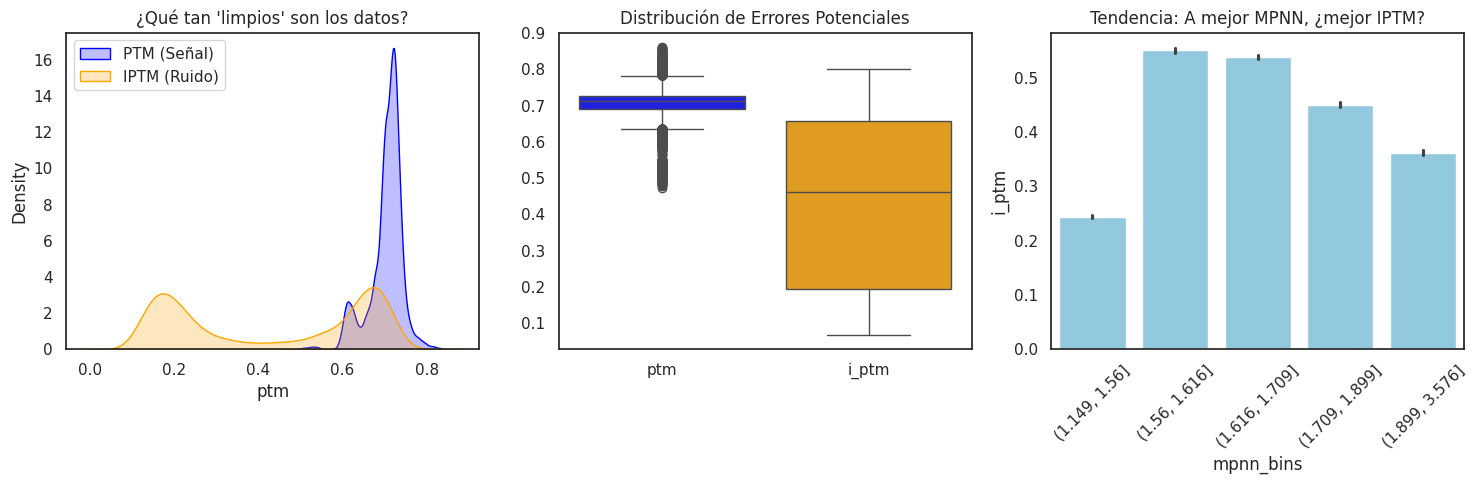

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_simpler_eda(df):
    plt.figure(figsize=(15, 5))
    sns.set_theme(style="white")

    # 1. Comparación de "Montañas" (Densidad)
    plt.subplot(1, 3, 1)
    sns.kdeplot(df['ptm'], shade=True, color="blue", label="PTM (Señal)")
    sns.kdeplot(df['i_ptm'], shade=True, color="orange", label="IPTM (Ruido)")
    plt.title("¿Qué tan 'limpios' son los datos?")
    plt.legend()

    # 2. El detector de Outliers (Cajas)
    plt.subplot(1, 3, 2)
    sns.boxplot(data=df[['ptm', 'i_ptm']], palette=["blue", "orange"])
    plt.title("Distribución de Errores Potenciales")

    # 3. La Brújula: Relación con MPNN (Score)
    plt.subplot(1, 3, 3)
    # Agrupamos por rangos para que no sean puntos locos
    df['mpnn_bins'] = pd.qcut(df['mpnn'], q=5)
    sns.barplot(data=df, x='mpnn_bins', y='i_ptm', color="skyblue")
    plt.xticks(rotation=45)
    plt.title("Tendencia: A mejor MPNN, ¿mejor IPTM?")

    plt.tight_layout()
    plt.show()

plot_simpler_eda(df)

In [5]:
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv('../data/Estructuras3.csv')

# Seleccionamos las métricas clave
metrics = ['ptm', 'i_ptm', 'mpnn', 'plddt', 'rmsd']

# 1. Estadísticos Básicos
stats = df[metrics].describe().T

# 2. Cálculo de Sesgo (Skewness) y Curtosis (Outliers)
stats['skew'] = df[metrics].skew() # Si es > 1 o < -1, hay mucho sesgo
stats['kurtosis'] = df[metrics].kurt() # Si es alta, hay muchos outliers que arruinan el MSE

print("📊 ANÁLISIS NUMÉRICO DEL DATASET:")
display(stats[['mean', 'std', 'min', '50%', 'max', 'skew', 'kurtosis']])

# 3. Cálculo de la "Señal de Ruido" (Coeficiente de Variación)
cv = (df['i_ptm'].std() / df['i_ptm'].mean()) * 100
print(f"\n⚠️ El IPTM tiene una variabilidad del {cv:.2f}%.")
if cv > 50:
    print("👉 NOTA: El ruido es alto. Necesitas regularización L1 (reg_alpha) fuerte.")

📊 ANÁLISIS NUMÉRICO DEL DATASET:


,mean,std,min,50%,max,skew,kurtosis
ptm,0.703107,0.040928,0.472,0.712,0.861,-1.151934,2.655722
i_ptm,0.428682,0.227126,0.067,0.461,0.801,-0.054125,-1.743420
mpnn,1.753929,0.293508,1.150,1.647,3.576,1.844492,3.583719
plddt,0.617008,0.126407,0.235,0.631,0.866,-0.523447,-0.608099
rmsd,9.966945,9.161805,0.952,5.674,65.729,1.523452,1.141364



⚠️ El IPTM tiene una variabilidad del 52.98%.
👉 NOTA: El ruido es alto. Necesitas regularización L1 (reg_alpha) fuerte.


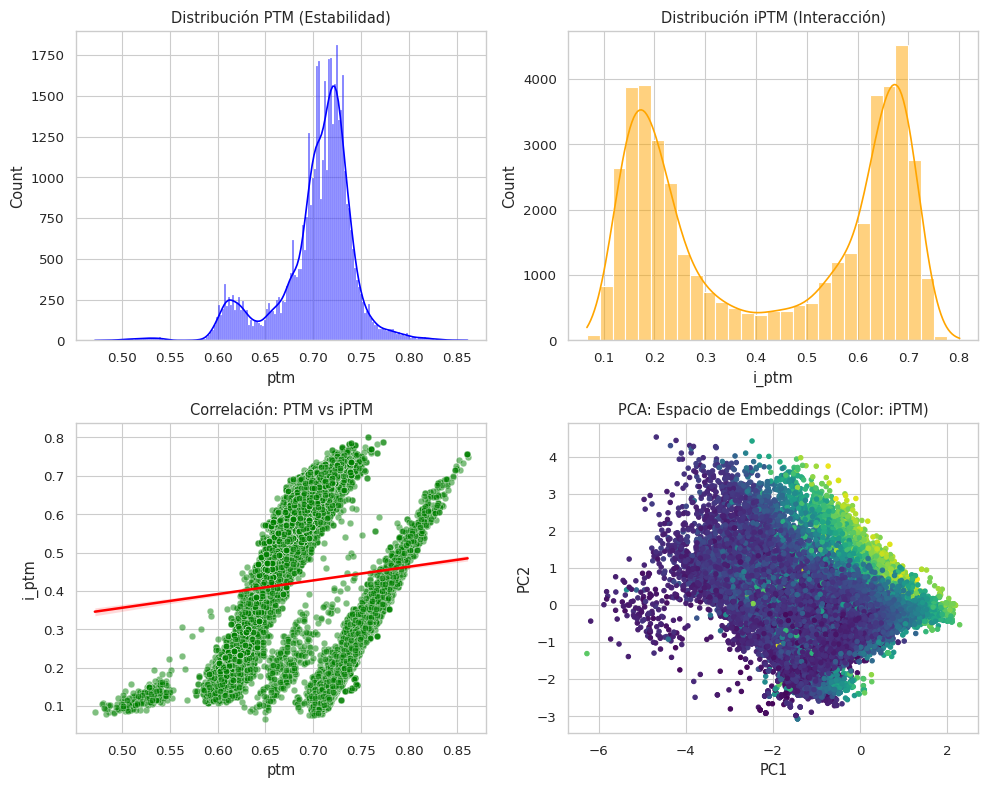

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def run_final_eda_plots(df):
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1.1)
    
    # Crear una figura con 4 subplots (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # 1. Histograma de PTM
    sns.histplot(df['ptm'], kde=True, color="blue", ax=axes[0, 0])
    axes[0, 0].set_title("Distribución PTM (Estabilidad)")
    
    # 2. Histograma de iPTM
    sns.histplot(df['i_ptm'], kde=True, color="orange", ax=axes[0, 1])
    axes[0, 1].set_title("Distribución iPTM (Interacción)")

    # 3. Correlación PTM vs iPTM (Relación de Calidad)
    sns.scatterplot(data=df, x='ptm', y='i_ptm', alpha=0.5, color="green", ax=axes[1, 0])
    sns.regplot(data=df, x='ptm', y='i_ptm', scatter=False, color="red", ax=axes[1, 0])
    axes[1, 0].set_title("Correlación: PTM vs iPTM")

    # 4. Distribución de Embeddings (PCA)
    # Seleccionamos columnas numéricas (excluyendo targets) para simular el espacio de embeddings
    features = ['mpnn', 'plddt', 'rmsd'] 
    x = StandardScaler().fit_transform(df[features])
    pca = PCA(n_components=2)
    components = pca.fit_transform(x)
    
    axes[1, 1].scatter(components[:, 0], components[:, 1], c=df['i_ptm'], cmap='viridis', s=10)
    axes[1, 1].set_title("PCA: Espacio de Embeddings (Color: iPTM)")
    axes[1, 1].set_xlabel("PC1")
    axes[1, 1].set_ylabel("PC2")

    plt.tight_layout()
    plt.show()

run_final_eda_plots(df)